In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Titanic-Dataset.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [9]:
#Preprocess the dataset
print("Missing values in the dataset: \n")
print(df.isnull().sum())      

#Handle missing data
df["Age"] = df["Age"].fillna(df["Age"].median())
print("\n")
print("Missing values in the dataset after handling AGE column: \n")
print(df.isnull().sum())       

Missing values in the dataset: 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Missing values in the dataset after handling AGE column: 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [11]:
# Feature Selection
from sklearn.model_selection import train_test_split
X = df[["Age", "Pclass", "SibSp", "Parch"]]
y = df["Fare"]
#Spliting the data into training and testing
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("DONE")

DONE


In [13]:
#Linear regression Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)
print("Model trained")

Model trained


In [14]:
#evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 19.781969090439063
MSE: 946.3355043476649
R2 Score: 0.3884468201561928


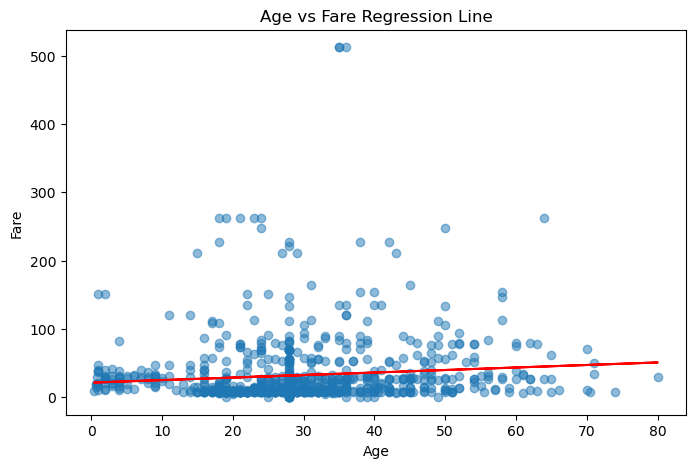

In [15]:
#Plot linear regression
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = df[["Age"]]
y = df["Fare"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.figure(figsize=(8,5))
plt.scatter(X, y, alpha=0.5)
plt.plot(X, y_pred, color="red")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare Regression Line")
plt.show()

In [16]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 21.368631241135958
Coefficient: 0.36903926178178814
